# SKU-level demand forecasting: analysis

Seven-day-ahead forecasts for 100 SKUs in one M5 (Walmart) store, scored on a held-out final 91 days, and a simulated reorder comparison built on the forecasts. M5 is retail data used here as a stand-in for dark-store demand. Every number below is read from files written by the pipeline in `src/`.

In [1]:
import os
os.chdir("..")  # run from the repo root so paths match the scripts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:.3f}".format
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
COLORS = {"lgbm": "#1f6f8b", "ma_28": "#e08e2b", "seasonal_naive_7": "#8c8c8c", "naive": "#c9c9c9"}
LABELS = {"lgbm": "LightGBM", "ma_28": "28-day moving average", "seasonal_naive_7": "Seasonal naive (7)", "naive": "Naive"}
SEGS = ["all", "fast", "medium", "intermittent"]

test = pd.read_csv("reports/model_test.csv")
val = pd.read_csv("reports/model_validation.csv").groupby(["segment", "model"], as_index=False)[["wape", "bias", "mae"]].mean()
print("Test period (scored once)")
test.pivot(index="segment", columns="model", values="wape").loc[SEGS]

Test period (scored once)


model,lgbm,ma_28,naive,seasonal_naive_7
segment,,,,
all,0.683,0.725,0.901,0.865
fast,0.576,0.628,0.793,0.741
medium,0.831,0.853,1.056,1.051
intermittent,1.100,1.110,1.315,1.319


## Test results by segment

WAPE is the primary metric. A forecast of zero on every day scores exactly 1.0, so values above 1.0 in the intermittent segment mean the forecast is worse than predicting no sales at all on that measure. MAE and bias are shown alongside for that reason.

In [2]:
for name, df in [("Test", test), ("Validation (mean of 3 folds)", val)]:
    print(name)
    print(df.pivot(index="segment", columns="model", values=["wape", "bias", "mae"]).loc[SEGS].round(3).to_string())
    print()

Test
              wape                                bias                                  mae                             
model         lgbm ma_28 naive seasonal_naive_7   lgbm  ma_28  naive seasonal_naive_7  lgbm ma_28 naive seasonal_naive_7
segment                                                                                                                 
all          0.683 0.725 0.901            0.865 -0.004  0.014  0.006            0.010 1.293 1.373 1.707            1.638
fast         0.576 0.628 0.793            0.741  0.000  0.039  0.010            0.019 2.218 2.421 3.053            2.855
medium       0.831 0.853 1.056            1.051 -0.031 -0.029  0.002            0.002 0.966 0.992 1.228            1.222
intermittent 1.100 1.110 1.315            1.319  0.016 -0.061 -0.019           -0.028 0.668 0.674 0.799            0.801

Validation (mean of 3 folds)
              wape                                bias                                  mae                           

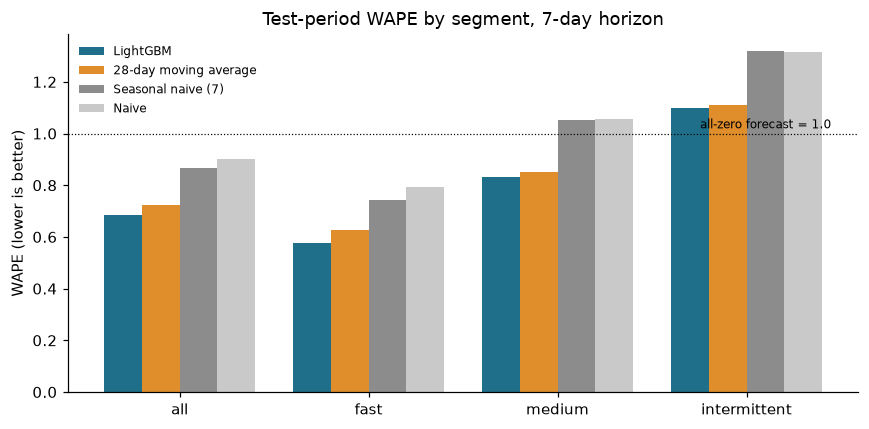

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
w = 0.2
for i, m in enumerate(["lgbm", "ma_28", "seasonal_naive_7", "naive"]):
    v = test[test.model == m].set_index("segment").loc[SEGS, "wape"]
    ax.bar(np.arange(4) + (i - 1.5) * w, v, w, label=LABELS[m], color=COLORS[m])
ax.axhline(1.0, color="black", lw=0.8, ls=":")
ax.text(3.45, 1.02, "all-zero forecast = 1.0", ha="right", fontsize=8)
ax.set_xticks(range(4)); ax.set_xticklabels(SEGS)
ax.set_ylabel("WAPE (lower is better)"); ax.set_title("Test-period WAPE by segment, 7-day horizon")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig("reports/wape_by_segment.png"); plt.show()

## Where the model beats the moving average, series by series

The pooled numbers hide how often the model actually wins. This counts SKUs by the test-period WAPE of each model, using all seven horizon steps.

In [4]:
p = pd.read_parquet("reports/test_predictions.parquet")
def series_wape(g, col): return (g[col] - g["y"]).abs().sum() / g["y"].sum()
per = p.groupby(["item_id", "segment"]).apply(
    lambda g: pd.Series({"lgbm": series_wape(g, "lgbm"), "ma_28": series_wape(g, "ma_28"), "sales": g["y"].sum()}),
    include_groups=False).reset_index()
per["lgbm_wins"] = per["lgbm"] < per["ma_28"]
print(per.groupby("segment")["lgbm_wins"].agg(["sum", "count"]))
print("all:", per["lgbm_wins"].sum(), "of", len(per))

              sum  count
segment                 
fast           28     34
intermittent   19     33
medium         23     33
all: 70 of 100


## Actual vs forecast

Series are chosen by rule, not by looks: the lowest-error fast SKU, the median-error SKU in each segment, and the highest-error fast or medium SKU as the poor example. Forecasts shown are the 1-day-ahead ones. The shaded band runs from the P50 to the P90 forecast.

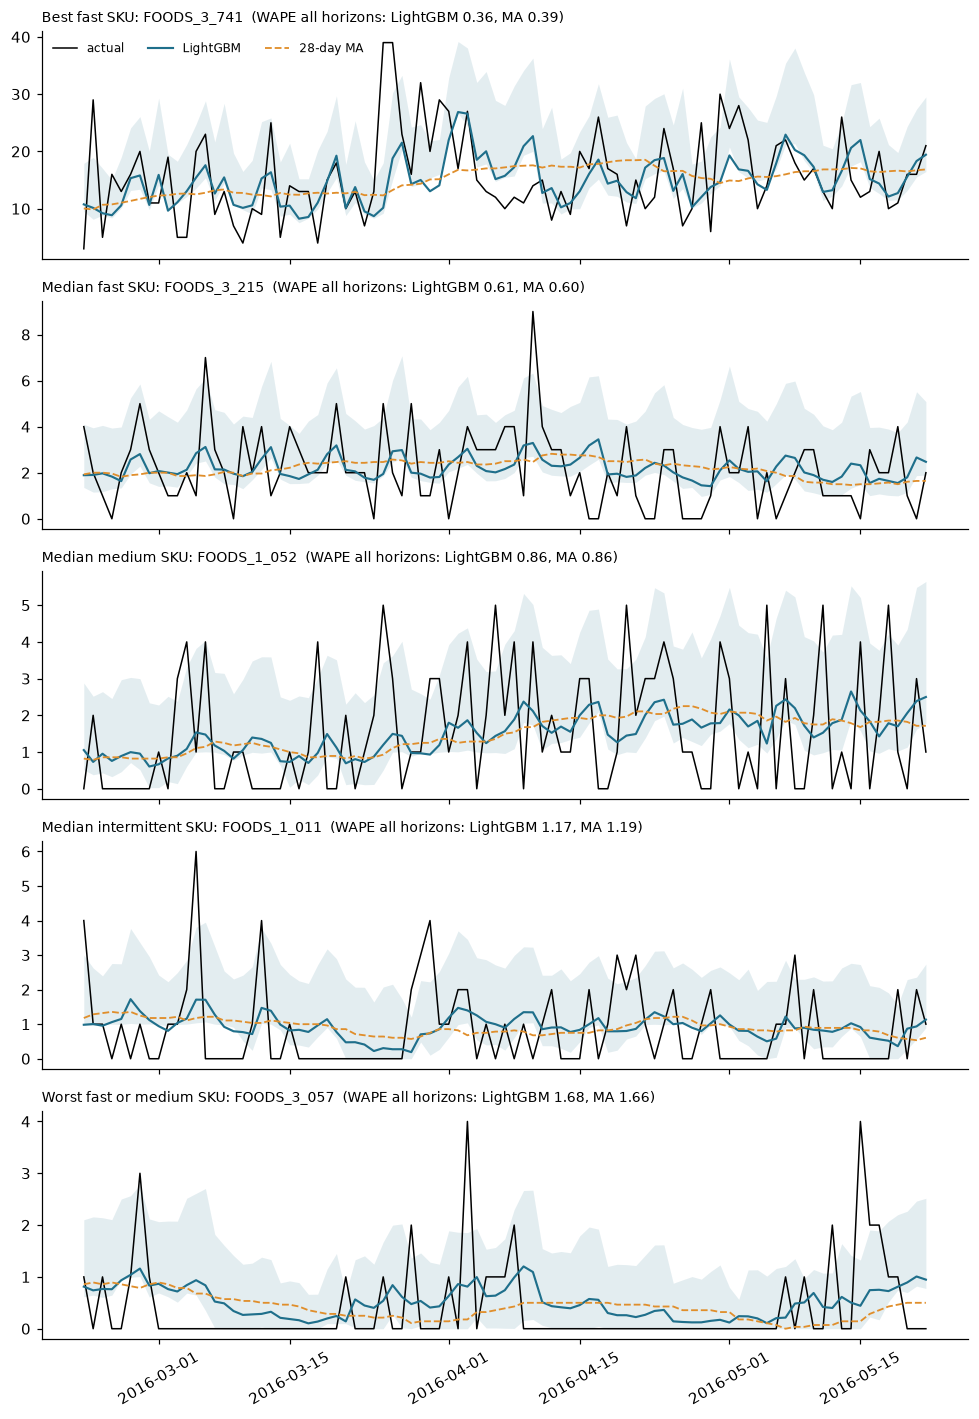

{'Best fast SKU': 'FOODS_3_741', 'Median fast SKU': 'FOODS_3_215', 'Median medium SKU': 'FOODS_1_052', 'Median intermittent SKU': 'FOODS_1_011', 'Worst fast or medium SKU': 'FOODS_3_057'}


In [5]:
cand = per[per.segment.isin(["fast", "medium"])]
picks = {
    "Best fast SKU": per[per.segment == "fast"].sort_values("lgbm").iloc[0],
    "Median fast SKU": per[per.segment == "fast"].sort_values("lgbm").iloc[len(per[per.segment == "fast"]) // 2],
    "Median medium SKU": per[per.segment == "medium"].sort_values("lgbm").iloc[len(per[per.segment == "medium"]) // 2],
    "Median intermittent SKU": per[per.segment == "intermittent"].sort_values("lgbm").iloc[len(per[per.segment == "intermittent"]) // 2],
    "Worst fast or medium SKU": cand.sort_values("lgbm").iloc[-1],
}
h1 = p[p.h == 1]
fig, axes = plt.subplots(len(picks), 1, figsize=(9, 2.6 * len(picks)), sharex=True)
for ax, (title, row) in zip(axes, picks.items()):
    g = h1[h1.item_id == row["item_id"]].sort_values("target_date")
    ax.fill_between(g["target_date"], g["q50"], g["q90"], color=COLORS["lgbm"], alpha=0.12, lw=0)
    ax.plot(g["target_date"], g["y"], color="black", lw=1, label="actual")
    ax.plot(g["target_date"], g["lgbm"], color=COLORS["lgbm"], lw=1.4, label="LightGBM")
    ax.plot(g["target_date"], g["ma_28"], color=COLORS["ma_28"], lw=1.2, ls="--", label="28-day MA")
    ax.set_title(f"{title}: {row['item_id']}  (WAPE all horizons: LightGBM {row['lgbm']:.2f}, MA {row['ma_28']:.2f})", fontsize=9, loc="left")
axes[0].legend(frameon=False, fontsize=8, ncol=3)
axes[-1].tick_params(axis="x", rotation=30)
fig.tight_layout(); fig.savefig("reports/actual_vs_forecast.png"); plt.show()
print({k: v["item_id"] for k, v in picks.items()})

## Feature importance

Share of total split gain in the final model. This describes what the model uses, not what causes demand.

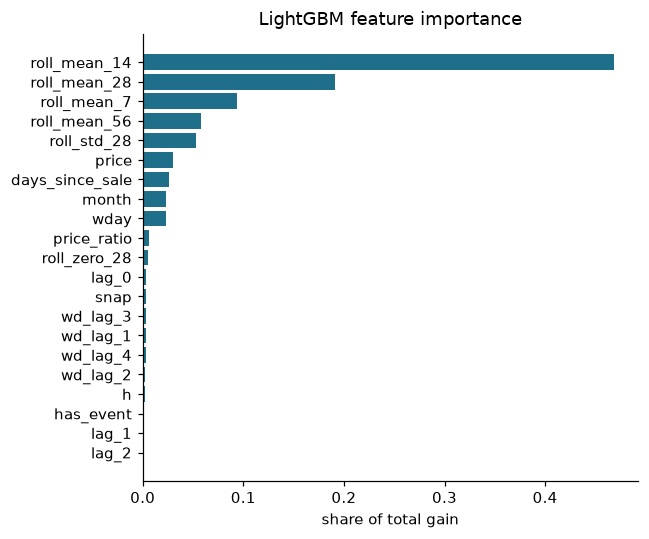

roll_mean_14      0.469
roll_mean_28      0.191
roll_mean_7       0.094
roll_mean_56      0.058
roll_std_28       0.053
price             0.030
days_since_sale   0.026
month             0.023
Name: gain_share, dtype: float64

In [6]:
imp = pd.read_csv("reports/feature_importance_final.csv", index_col=0)["gain_share"].sort_values()
fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(imp.index, imp.values, color=COLORS["lgbm"])
ax.set_xlabel("share of total gain"); ax.set_title("LightGBM feature importance")
fig.tight_layout(); fig.savefig("reports/feature_importance.png"); plt.show()
imp.sort_values(ascending=False).head(8)

## Quantile forecast calibration

The reorder step relies on the P90 forecast. Coverage is the share of actual days at or below the forecast.

In [7]:
pd.read_csv("reports/quantile_test.csv").set_index("segment").loc[SEGS]

,q50_pinball,q50_coverage,q90_pinball,q90_coverage
segment,,,,
all,0.614,0.579,0.379,0.903
fast,1.074,0.527,0.633,0.906
medium,0.465,0.550,0.279,0.892
intermittent,0.290,0.661,0.216,0.910


## Reorder simulation (simulated)

Nothing here is observed inventory. Daily review, 2-day lead time, order-up-to level, unmet demand lost, same starting stock for every policy. The moving-average policy orders up to P x its 28-day mean; the P50 and P90 policies order up to the sum of the daily P50 or P90 forecasts over the lead time. The P90 level adds daily P90s, which overstates the P90 of the total, so it is conservative. Full assumptions are in `docs/assumptions.md`.

In [8]:
sim = pd.read_csv("reports/simulation_results.csv")
sim.pivot(index="segment", columns="policy", values=["fill_rate", "stockout_day_share", "avg_inventory_units"]).loc[SEGS].round(3)

fill_rate             stockout_day_share              \
policy       moving_average   p50   p90     moving_average   p50   p90   
segment                                                                  
all                   0.745 0.694 0.970              0.181 0.224 0.019   
fast                  0.770 0.731 0.972              0.238 0.290 0.022   
medium                0.707 0.634 0.967              0.180 0.225 0.020   
intermittent          0.647 0.570 0.961              0.125 0.155 0.014   

             avg_inventory_units              
policy            moving_average   p50   p90  
segment                                       
all                        1.790 1.444 5.858  
fast                       3.148 2.480 9.702  
medium                     1.217 1.005 4.206  
intermittent               0.965 0.816 3.550

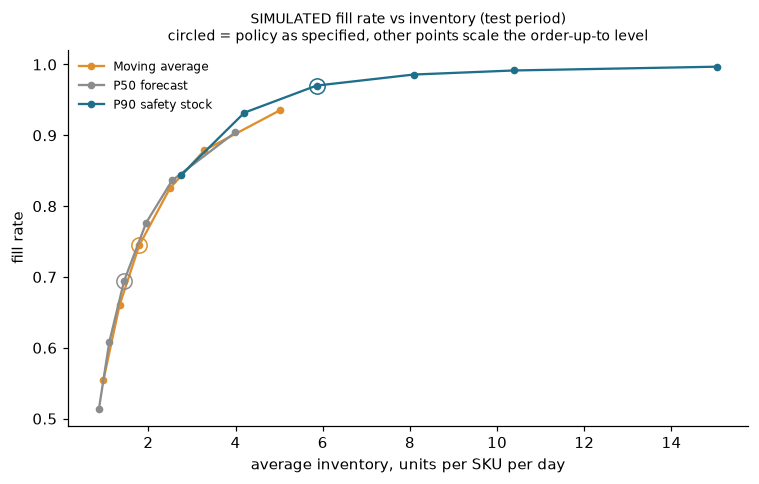

In [9]:
sw = pd.read_csv("reports/simulation_sweep.csv")
sw = sw[sw.segment == "all"]
names = {"moving_average": "Moving average", "p50": "P50 forecast", "p90": "P90 safety stock"}
cols = {"moving_average": COLORS["ma_28"], "p50": "#8c8c8c", "p90": COLORS["lgbm"]}
fig, ax = plt.subplots(figsize=(7, 4.5))
for pol, g in sw.groupby("policy"):
    g = g.sort_values("multiplier")
    ax.plot(g["avg_inventory_units"], g["fill_rate"], "-o", ms=4, color=cols[pol], label=names[pol])
    one = g[g.multiplier == 1.0]
    ax.plot(one["avg_inventory_units"], one["fill_rate"], "o", ms=10, mfc="none", color=cols[pol])
ax.set_xlabel("average inventory, units per SKU per day"); ax.set_ylabel("fill rate")
ax.set_title("SIMULATED fill rate vs inventory (test period)\ncircled = policy as specified, other points scale the order-up-to level", fontsize=9)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig("reports/simulation_tradeoff.png"); plt.show()

### At equal inventory

The raw comparison favours whichever policy holds more stock. To separate forecast quality from stock level, read each policy's fill rate at the same average inventory by interpolating the moving-average curve (this is only valid inside the range the curve covers).

In [10]:
ma = sw[sw.policy == "moving_average"].sort_values("avg_inventory_units")
rows = []
for pol in ["p50", "p90"]:
    for _, r in sw[(sw.policy == pol)].iterrows():
        inv = r["avg_inventory_units"]
        if ma["avg_inventory_units"].min() <= inv <= ma["avg_inventory_units"].max():
            rows.append({"policy": pol, "multiplier": r["multiplier"], "avg_inventory": inv, "fill_rate": r["fill_rate"],
                         "moving_average_fill_rate_at_same_inventory": np.interp(inv, ma["avg_inventory_units"], ma["fill_rate"])})
eq = pd.DataFrame(rows)
eq["difference"] = eq["fill_rate"] - eq["moving_average_fill_rate_at_same_inventory"]
eq

,policy,multiplier,avg_inventory,fill_rate,moving_average_fill_rate_at_same_inventory,difference
0,p50,0.800,1.103,0.608,0.593,0.015
1,p50,1.000,1.444,0.694,0.680,0.015
2,p50,1.250,1.950,0.777,0.763,0.014
3,p50,1.500,2.545,0.836,0.829,0.007
4,p50,2.000,3.992,0.904,0.902,0.002
5,p90,0.600,2.752,0.844,0.843,0.001
6,p90,0.800,4.204,0.932,0.909,0.023
